<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab 11: Generative AI</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 24 May, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging but make sure to wrap these in an ``if is_notebook:`` conditional so that it does not run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [1]:
# TODO: Replace with your name and university ID
student_name = "Weiyi Jiang"
student_id = "u8191809"

In [2]:
import sys
import getpass

def is_notebook():
    return 'ipykernel' in sys.modules

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.distributions import Normal

from typing import Optional

print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
print("Python Version: {}".format(sys.version))
print("PyTorch Version: {}".format(torch.__version__))

User: cichlidfish (Weiyi Jiang, u8191809)
Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
PyTorch Version: 2.10.0


### Generative Models

In a sentence, generative models aim to sample from the data distribution $p(X)$. They do this by first learning a model from *samples* from $p(X)$, i.e., the dataset. 

### The Ground-Truth Data Distribution

Let's consider a complex 1-D data distribution that is hard for classical ML algorithms like Expectation-Maximisation:

$$p(X=x) = \frac{\exp{\left\{-x^2 + 2\cdot\log\left(1 + \sin(4x)^2\right) + x\right\}}}{\int_\mathbb{R}{\exp{\left\{-x^2 + 2\cdot\log\left(1 + \sin(4x)^2\right) + x\right\}}}dx} $$

In [3]:
def logp_data_unnorm(x):
    return -x ** 2 + 2 * torch.log1p(torch.sin(4*x) ** 2) + x

This distribution is the **goal** of generative models, meaning it's **not** known in general. We spell the exact distribution out just to evaluate how good our VAE/Diffusion models are. We obtain $100$ samples from this distribution via rejection sampling as our training set:

In [4]:
@torch.no_grad()
def sample(n, grid, sigma=2.5, batch=200_000):
    q = Normal(torch.tensor(0.0), torch.tensor(sigma))
    log_M = (logp_data_unnorm(grid) - q.log_prob(grid)).max() + 0.1  

    out = []
    while sum(t.numel() for t in out) < n:
        x = q.sample((batch,))
        log_u = torch.rand(batch).log()
        out.append(x[log_u < logp_data_unnorm(x) - q.log_prob(x) - log_M])
    return torch.cat(out)[:n]

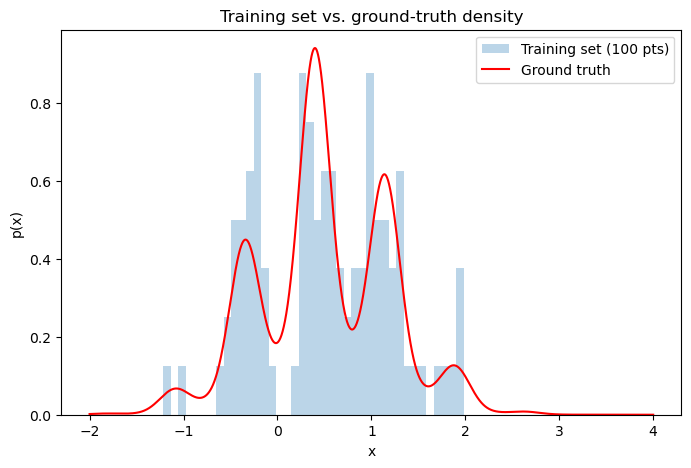

In [5]:
if is_notebook():
    torch.manual_seed(0)
    grid = torch.linspace(-2, 4, 4001)
    samples = sample(100, grid)

    log_p = logp_data_unnorm(grid)
    log_p = log_p - log_p.max()
    p_unnorm = log_p.exp()
    p = p_unnorm / torch.trapz(p_unnorm, grid)

    plt.figure(figsize=(8, 5))
    plt.hist(samples.numpy(), bins=40, density=True, alpha=0.3, label='Training set (100 pts)')
    plt.plot(grid.numpy(), p.numpy(), 'r-', label='Ground truth')
    plt.xlabel('x')
    plt.ylabel('p(x)')
    plt.legend()
    plt.title('Training set vs. ground-truth density')
    plt.show()

Clearly the empirical distribution is far from the ground truth. How do we use generative models to improve this?

### Evidence Lower Bound (ELBO)

Introducing a latent variable $Z \sim p(Z)$, a dataset $\mathcal{D} = \{x_i\}_{i=1}^N$. the ELBO is defined as $$L_{ELBO}(q) = \sum_{i=1}^{N}\left(\mathbb{E}_{z\sim q(z|x_i)}\left[\log p(x_i|z) \right] - D_{KL}\left(q(z|x_i)\Vert p(z)\right)\right)$$

You might have thought about why the name "Evidence Lower Bound". It's actually quite straightforward:
- The "Evidence" part is from the objective $p(\mathcal{D}) = \prod_{i=1}^N p(X = x_i)$. $p(\mathcal{D})$ is called "marginal likelihood" or "evidence". You might have seen this on the denominator of the Bayes' rule: $$p(w|\mathcal{D}) = \frac{p(\mathcal{D}|w)p(w)}{p(\mathcal{D})}$$
- The "Lower Bound" part is from the fact that $\ln p(\mathcal{D}) \ge L_{ELBO}(q)$, which can be shown using Jensen's inequality. Alternatively, one explicitly write out the gap: $$\ln p(\mathcal{D}) = L_{ELBO}(q) + \sum_{i=1}^N D_{KL}\left(q(z|x_i)\Vert p(z|x_i)\right)$$As KL-divergence is guaranteed to be non-negative, $\ln p(\mathcal{D}) \ge L_{ELBO}(q)$. 

ELBO is a very important result in variational inference. The name "variational" is coming from how people optimise the ELBO traditionally. As ELBO takes a *distribution* $q$ as its input, calculus of variations was needed in general (but not always). 

### Variational AutoEncoders (VAEs)



VAEs provide a NN-based solution to ELBOs. Instead of dealing with distributions $q$ directly, VAEs considered NN-parameterised distributions, and optimise the weights of neural networks instead.
$$L_{ELBO}(\phi, \theta) = \sum_{i=1}^{N}\left(\mathbb{E}_{z\sim q(z|x_i; \theta)}\left[\log p(x_i|z; \phi) \right] - D_{KL}\left(q(z|x_i; \theta)\Vert p(z)\right)\right)$$

To make things as tractable and efficient as possible, vanilla VAEs approximate these distributions as follows:
- $p(z) = \mathcal{N}(0, \mathbf{I})$
- $q(z|x_i; \theta) = \mathcal{N}\left(\mu_{\text{enc}}, \mathrm{diag}(\sigma^2_{\text{enc}})\right)$
- $p(x_i|z; \phi) = \mathcal{N}\left(\mu_{\text{dec}}, \mathrm{diag}(\sigma^2_{\text{dec}})\right)$


where $\mathrm{diag}(a)$ creates a diagonal matrix whose diagonal is $a$. Distributional parameters are from neural networks
- $f_{\theta}(x_i) = (\mu_{\text{enc}}, \ln\sigma^2_{\text{enc}})$
- $g_{\phi}(z) = (\mu_{\text{dec}}, \ln\sigma^2_{\text{dec}})$

With these approximations, the KL-divergence can be computed closed-form:

$$D_{KL}\!\left(q(z|x_i; \theta)\,\Vert\,p(z)\right) = \frac{1}{2}\sum_{d=1}^{D_z}\left[\mu_{\text{enc},d}^2 + \sigma^2_{\text{enc},d} - 1 - \ln\sigma^2_{\text{enc},d}\right]$$

However, despite all these approximations, the expectation term $\mathbb{E}_{z\sim q(z|x_i; \theta)}\left[\log p(x_i|z; \phi) \right]$ remains intractable. In practice, this is approximated with Monte-Carlo approximation:

$$\mathbb{E}_{z\sim q(z|x_i; \theta)}\left[\log p(x_i|z; \phi)\right] \;\approx\; \frac{1}{M}\sum_{m=1}^{M}\log p\!\left(x_i\,\big|\,z^{(m)};\phi\right),\quad z^{(m)} \sim q(z|x_i; \theta)$$

where, for the diagonal-Gaussian likelihood above,

$$\log p(x_i|z^{(m)}; \phi) = -\frac{1}{2}\sum_{d=1}^{D_x}\!\left[\ln(2\pi) + \ln\sigma^2_{\text{dec},d} + \frac{(x_{i,d} - \mu_{\text{dec},d})^2}{\sigma^2_{\text{dec},d}}\right]$$

### Task 1: The Encoder / Decoder Building Block

The two networks $f_\theta$ and $g_\phi$ above share an identical structure: each takes a
vector input and outputs the mean and the log-variance of a diagonal Gaussian. We therefore
implement a single MLP-based building block, `GaussianMLP`, and reuse it as the VAE encoder
$f_\theta$, the VAE decoder $g_\phi$, *and* (later) the DDPM denoiser.

Given an input of shape `(B, in_dim)`, `GaussianMLP` should produce two outputs each of
shape `(B, out_dim)`:
- the mean (i.e. $\mu_\text{enc}$ when used as the encoder, $\mu_\text{dec}$ when used as the decoder), and
- the log-variance (i.e. $\ln\sigma^2_\text{enc}$ or $\ln\sigma^2_\text{dec}$).

Concretely, the architecture is:
```
Linear(in_dim   -> hidden[0]) -> ReLU
Linear(hidden[0]-> hidden[1]) -> ReLU
...
Linear(hidden[-1] -> 2 * out_dim)
```
The final layer outputs `2 * out_dim` numbers; split them in half along the feature axis
to obtain `mu` (first half) and `logvar` (second half).

Use ReLU activations between linear layers, and **no** activation on the final layer.

In [6]:
class GaussianMLP(nn.Module):
    """
    MLP that parameterises a diagonal Gaussian N(mu, diag(exp(logvar))).

    Used as the building block for:
      - VAE encoder       q(z | x; theta)
      - VAE decoder       p(x | z; phi)
      - DDPM denoiser     p(x_{t-1} | x_t) (mu output is taken as predicted noise)

    Parameters
    ----------
    in_dim  : int        - input dimensionality
    out_dim : int        - dimensionality of the Gaussian (mu and logvar each have this size)
    hidden  : list[int]  - hidden layer widths, each followed by ReLU
    """

    def __init__(self, in_dim: int, out_dim: int, hidden: list[int]) -> None:
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        layers: list[nn.Module] = []
        # TODO TASK 1a:
        # build the MLP layers as described above by adding Modules to the `layers` array.
        # These will be turned into a sequential network in the final line below.
        prev_dim = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 2 * out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # TODO TASK 1b:
        # implement the forward functio to obtain mu and logvar.
        out = self.net(x)
        mu, logvar = torch.chunk(out, 2, dim=-1)
        return mu, logvar


In [7]:
if is_notebook():
    block = GaussianMLP(in_dim=4, out_dim=3, hidden=[16, 16])

    linear_layers = [m for m in block.net if isinstance(m, nn.Linear)]
    assert list(linear_layers[0].weight.shape) == [16, 4],  f"Layer 0 wrong: {list(linear_layers[0].weight.shape)}"
    assert list(linear_layers[1].weight.shape) == [16, 16], f"Layer 1 wrong: {list(linear_layers[1].weight.shape)}"
    assert list(linear_layers[2].weight.shape) == [6, 16],  f"Last layer should output 2*out_dim=6 units, got {list(linear_layers[2].weight.shape)}"
    print("Layer dimension checks passed!")

    n_relus = sum(1 for m in block.net if isinstance(m, nn.ReLU))
    assert n_relus == 2, f"Expected 2 ReLU activations between 3 Linear layers, got {n_relus}"
    print("Activation count check passed!")

    dummy = torch.zeros(5, 4)
    mu, logvar = block(dummy)
    assert mu.shape == (5, 3) and logvar.shape == (5, 3), f"Wrong output shape: mu={mu.shape}, logvar={logvar.shape}"
    print("Output shape check passed!")


Layer dimension checks passed!
Activation count check passed!
Output shape check passed!


### Task 2: The Reparameterisation Trick and the ELBO

The Monte-Carlo estimate above tells us how to approximate the intractable expectation, but it leaves one practical obstacle: drawing $z \sim q(z|x_i; \theta) = \mathcal{N}(\mu_\text{enc}, \mathrm{diag}(\sigma^2_\text{enc}))$ directly is **not** differentiable w.r.t. $(\mu_\text{enc}, \sigma^2_\text{enc})$, so gradients cannot flow back into the encoder $f_\theta$. The reparameterisation trick fixes this by pushing the randomness into a parameter-free noise variable,
$$z = \mu_\text{enc} + \sigma_\text{enc} \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \mathbf{I}),$$
so that $z$ becomes a deterministic, differentiable function of $(\mu_\text{enc}, \sigma_\text{enc})$ plus the noise $\epsilon$, and gradients flow as expected.

Combining the closed-form KL with the $M$-sample Monte-Carlo estimate of the reconstruction, and applying the reparameterisation trick gives the per-example training loss

$$-\hat{L}_{\mathrm{ELBO}}(x_i;\,\phi,\theta) \;=\; -\frac{1}{M}\sum_{m=1}^{M}\log p\!\left(x_i\,\big|\,z^{(m)};\,\phi\right) \;+\; D_{KL}\!\left(q(z|x_i;\theta)\,\Vert\, p(z)\right),$$

with $z^{(m)} = \mu_\text{enc} + \sigma_\text{enc} \odot \epsilon^{(m)}$ and $\epsilon^{(m)} \sim \mathcal{N}(0, \mathbf{I})$. Sum each term over its feature dimensions ($d = 1, \ldots, D_x$ for the reconstruction and $d = 1, \ldots, D_z$ for the KL), then **average** over the batch.

In [8]:
class VAE(nn.Module):
    """
    Variational Auto-Encoder with diagonal-Gaussian encoder and decoder.

    Parameters
    ----------
    x_dim  : int        - dimensionality of the data
    z_dim  : int        - dimensionality of the latent variable
    hidden : list[int]  - hidden layer widths shared by encoder and decoder
    """

    def __init__(self, x_dim: int = 1, z_dim: int = 2, hidden: list[int] = [64, 64]) -> None:
        super().__init__()
        self.x_dim = x_dim
        self.z_dim = z_dim
        self.encoder = GaussianMLP(x_dim, z_dim, hidden)
        self.decoder = GaussianMLP(z_dim, x_dim, hidden)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """
        Sample z ~ N(mu, diag(exp(logvar))) using the reparameterisation trick so that
        gradients flow through `mu` and `logvar`.
        """
        # TODO TASK 2a: implement the reparameterisation trick.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def elbo_loss(self, x: torch.Tensor, M: int = 1) -> torch.Tensor:
        """
        Compute the negative ELBO averaged over the batch using `M` Monte-Carlo samples
        of the reconstruction term. Returns a scalar tensor that can be back-propagated.
        """
        # TODO TASK 2b:
        # implement the ELBO loss. Try not to include a for loop.
        # Hint: use the `encoder` and `decoder` networks and the `reparameterize` method implemented
        # above, and well as other necessary expressions and glue code.
        mu_z, logvar_z = self.encoder(x)
        mu_z_mc = mu_z.unsqueeze(0).expand(M, -1, -1)
        logvar_z_mc = logvar_z.unsqueeze(0).expand(M, -1, -1)
        z = self.reparameterize(mu_z_mc, logvar_z_mc)

        mu_x, logvar_x = self.decoder(z.reshape(M * x.shape[0], self.z_dim))
        mu_x = mu_x.reshape(M, x.shape[0], self.x_dim)
        logvar_x = logvar_x.reshape(M, x.shape[0], self.x_dim)

        x_mc = x.unsqueeze(0)
        recon_logprob = -0.5 * (
            np.log(2 * np.pi)
            + logvar_x
            + (x_mc - mu_x).pow(2) / torch.exp(logvar_x)
        ).sum(dim=-1)
        recon_term = recon_logprob.mean(dim=0)

        kl = 0.5 * (mu_z.pow(2) + torch.exp(logvar_z) - 1 - logvar_z).sum(dim=-1)
        return (-recon_term + kl).mean()

    @torch.no_grad()
    def sample(self, n: int) -> torch.Tensor:
        """Draw `n` samples from the trained generative model p(x) = E_{p(z)} p(x|z)."""
        device = next(self.parameters()).device
        z = torch.randn(n, self.z_dim, device=device)
        mu_x, logvar_x = self.decoder(z)
        x = mu_x + torch.exp(0.5 * logvar_x) * torch.randn_like(mu_x)
        return x


In [9]:
if is_notebook():
    torch.manual_seed(0)
    vae_test = VAE(x_dim=1, z_dim=2, hidden=[16, 16])

    # reparameterisation trick: empirical mean/std should match the supplied params,
    # and sigma=0 (logvar -> -inf) should give a deterministic z = mu.
    mu = torch.tensor([[1.0, -2.0]]).expand(20000, 2).contiguous()
    logvar = torch.log(torch.tensor([[0.25, 4.0]])).expand(20000, 2).contiguous()
    z = vae_test.reparameterize(mu, logvar)
    assert z.shape == mu.shape, f"reparameterize shape wrong: {z.shape}"
    assert torch.allclose(z.mean(0), mu[0], atol=0.05), f"empirical mean off: {z.mean(0)}"
    assert torch.allclose(z.std(0),  torch.tensor([0.5, 2.0]), atol=0.1), f"empirical std off: {z.std(0)}"
    print("Reparameterisation mean/std check passed!")

    # gradients should flow through mu and logvar
    mu_g = torch.zeros(8, 2, requires_grad=True)
    lv_g = torch.zeros(8, 2, requires_grad=True)
    vae_test.reparameterize(mu_g, lv_g).sum().backward()
    assert mu_g.grad is not None and lv_g.grad is not None, "gradient did not flow through reparameterize"
    print("Reparameterisation gradient check passed!")

    # ELBO loss: must be a scalar, finite, and reduce when we cheat with perfect reconstruction
    x_dummy = torch.randn(32, 1)
    loss = vae_test.elbo_loss(x_dummy, 10)
    assert loss.dim() == 0, f"elbo_loss must return a scalar, got shape {loss.shape}"
    assert torch.isfinite(loss), f"elbo_loss returned non-finite value {loss.item()}"
    print(f"ELBO loss returns scalar = {loss.item():.4f}")


Reparameterisation mean/std check passed!
Reparameterisation gradient check passed!
ELBO loss returns scalar = 1.3962


### Training and Sampling From the VAE

We are now ready to train the VAE on the 100 samples drawn from the ground-truth
distribution. We use full-batch gradient descent for simplicity. Once trained, we draw
samples from the prior $z\sim p(z) = \mathcal{N}(0, I)$ and pass them through the
decoder to obtain samples in data space, $x \sim p(x|z;\phi)$. If learning succeeded,
the histogram of these samples should approximate the (red) ground-truth pdf much better
than the empirical histogram of the 100 training points alone.

epoch  1000 / 20000    -ELBO = 1.0581
epoch  2000 / 20000    -ELBO = 1.0615
epoch  3000 / 20000    -ELBO = 1.0755
epoch  4000 / 20000    -ELBO = 1.0022
epoch  5000 / 20000    -ELBO = 0.9367
epoch  6000 / 20000    -ELBO = 0.9273
epoch  7000 / 20000    -ELBO = 0.9763
epoch  8000 / 20000    -ELBO = 0.9285
epoch  9000 / 20000    -ELBO = 0.9236
epoch 10000 / 20000    -ELBO = 0.9065
epoch 11000 / 20000    -ELBO = 0.9077
epoch 12000 / 20000    -ELBO = 0.8698
epoch 13000 / 20000    -ELBO = 0.8711
epoch 14000 / 20000    -ELBO = 0.8691
epoch 15000 / 20000    -ELBO = 0.8636
epoch 16000 / 20000    -ELBO = 0.8818
epoch 17000 / 20000    -ELBO = 0.8645
epoch 18000 / 20000    -ELBO = 0.8720
epoch 19000 / 20000    -ELBO = 0.8707
epoch 20000 / 20000    -ELBO = 0.8679


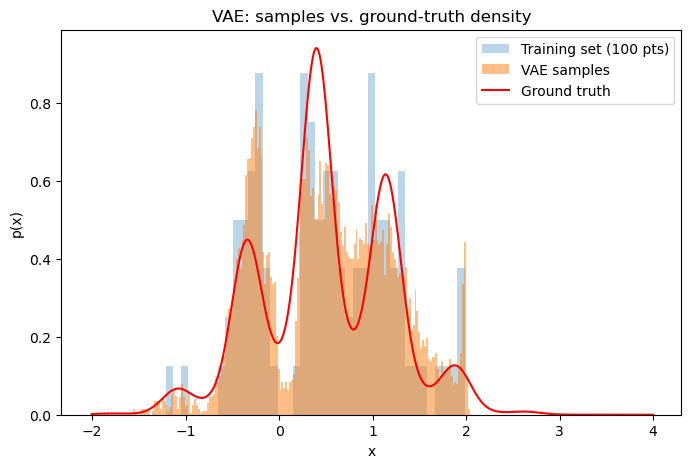

In [10]:
if is_notebook():
    torch.manual_seed(0)
    grid = torch.linspace(-2, 4, 4001)
    train_samples = sample(100, grid).unsqueeze(-1)  # (100, 1)

    log_p = logp_data_unnorm(grid)
    log_p = log_p - log_p.max()
    p_unnorm = log_p.exp()
    p = p_unnorm / torch.trapz(p_unnorm, grid)

    vae = VAE(x_dim=1, z_dim=2, hidden=[32, 32])
    optimizer = optim.Adam(vae.parameters(), lr=5e-4)

    n_epochs = 20000
    for epoch in range(n_epochs):
        loss = vae.elbo_loss(train_samples, 20)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 1000 == 0:
            print(f"epoch {epoch + 1:5d} / {n_epochs}    -ELBO = {loss.item():.4f}")

    vae.eval()
    x_samples = vae.sample(10000).cpu().numpy().flatten()

    plt.figure(figsize=(8, 5))
    plt.hist(train_samples.numpy().flatten(), bins=40, density=True, alpha=0.3,
             label='Training set (100 pts)')
    plt.hist(x_samples, bins=200, density=True, alpha=0.5, label='VAE samples')
    plt.plot(grid.numpy(), p.numpy(), 'r-', label='Ground truth')
    plt.xlabel('x')
    plt.ylabel('p(x)')
    plt.legend()
    plt.title('VAE: samples vs. ground-truth density')
    plt.show()


You should be able to see the empirical distribution generated from VAE samples matching the ground truth much better. 

### Denoising Diffusion Probabilistic Models (DDPM)

A VAE compresses each data point into a single latent vector $z$ and reconstructs it in one decoding step. DDPMs take the opposite approach: instead of one big jump, they break the generative process into many tiny denoising steps. Think of clean images being slowly corrupted into pure noise over $T$ frames. A DDPM learns the reverse - generate clean images from the pure noise.

This buys us a much easier learning problem. Each individual step is only a small perturbation, so the network never has to model the entire complicated data distribution at once. It only has to undo a tiny amount of Gaussian noise. The price we pay is that sampling requires running the full chain of $T$ steps.

The forward (noising) process is fixed: at each step $t$ we add a little bit of Gaussian noise on top of whatever we had at step $t-1$,
$$q(x_t | x_{t-1}) = \mathcal{N}\!\left(\sqrt{1-\beta_t}\, x_{t-1},\; \beta_t \mathbf{I}\right), \qquad t = 1, \ldots, T,$$
with $\beta_t$ a small noise schedule (typically a linear ramp from $10^{-4}$ to $0.02$). Crucially, **no learnable parameters** appear here — it is just a fixed recipe applied to the data. After enough steps the original data is completely forgotten and $x_T \approx \mathcal{N}(0, \mathbf{I})$.

A nice property of chained Gaussians is that we can jump straight to any time step in closed form,
$$q(x_t | x_0) = \mathcal{N}\!\left(\sqrt{\bar\alpha_t}\, x_0,\; (1 - \bar\alpha_t) \mathbf{I}\right), \qquad \alpha_t := 1 - \beta_t,\;\; \bar\alpha_t := \prod_{s=1}^t \alpha_s,$$
or, equivalently, $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon$ with $\epsilon \sim \mathcal{N}(0, \mathbf{I})$. We will use this short-cut at training time so we never have to simulate the chain step by step.

The reverse (denoising) process is what we actually train. Given a noisy $x_t$ and the time index $t$, we model where it likely came from one step earlier as another Gaussian,
$$p(x_{t-1} | x_t;\,\phi) = \mathcal{N}\!\left(\mu_\phi(x_t, t),\; \sigma_t^2 \mathbf{I}\right),$$
where the mean $\mu_\phi$ is the output of a neural network. For simplicity we fix the variance to $\sigma_t^2 = \beta_t$ rather than learning it.

You might recognise this setup as a *stacked VAE*. A DDPM is exactly a hierarchical VAE with $T$ latent variables $x_1, x_2, \ldots, x_T$ that live in the same space as the data, in which the encoder is fixed and only the decoder is learned. Each denoising step $p(x_{t-1} | x_t;\,\phi)$ is a *VAE decoder*: it takes a vector input and outputs the parameters of a Gaussian. That is exactly what our `GaussianMLP` from Task 1 was designed to do, so we can plug it in directly as the DDPM denoiser — only the input and output dimensions change.

Writing the full ELBO for a $T$-step hierarchical VAE looks daunting, but Ho et al. (2020) showed that optimising it is equivalent to a much simpler MSE objective: ask the network to predict the noise $\epsilon$ that was added to $x_0$ to produce $x_t$, and minimise
$$\mathcal{L}_{\text{DDPM}} = \mathbb{E}_{t,\,x_0,\,\epsilon}\!\left[\,\bigl\Vert\,\epsilon - \epsilon_\phi(x_t, t)\,\bigr\Vert^2\,\right].$$
A single training iteration is therefore really easy: sample a random $t$, draw a random noise $\epsilon$, build $x_t$ from the closed-form short-cut above, feed $(x_t, t)$ through the network, and regress on $\epsilon$. We will use the `mu` output of `GaussianMLP` to produce $\epsilon_\phi(x_t, t)$ and ignore the `logvar` head (this is what fixing $\sigma_t^2 = \beta_t$ corresponds to).

Once the denoiser is trained, generating a sample means starting from pure noise $x_T \sim \mathcal{N}(0, \mathbf{I})$ and iteratively cleaning it up. The reverse step (which can be derived from $p(x_{t-1}|x_t;\phi)$) is
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\phi(x_t, t)\right) + \sqrt{\beta_t}\, z,\qquad z\sim\mathcal{N}(0,\mathbf{I}),$$
applied for $t = T, T-1, \ldots, 1$. On the very last step we drop the extra $z$ — the final sample shouldn't carry any residual noise. The resulting $x_0$ is our generated data point.

### Task 3: Implementing the DDPM

Most of the boilerplate (the noise schedule $\beta_t, \alpha_t, \bar\alpha_t$) has been written for
you. Your job is to fill in:
* **3a** — instantiate the denoiser as a `GaussianMLP`. The denoiser takes the concatenation of
  $x_t$ and the normalised time $t/T$ as input, so its input dimension is `x_dim + 1`.
* **3b** — the closed-form forward (noising) process $q(x_t | x_0)$.
* **3c** — the simplified DDPM training loss.
* **3d** — the ancestral sampling loop.


In [11]:
class DDPM(nn.Module):
    """
    Denoising Diffusion Probabilistic Model on a 1-D toy distribution.

    The denoiser network is a `GaussianMLP` (the same block we used for the VAE
    encoder / decoder). Its `mu` output is interpreted as the predicted noise
    epsilon_phi(x_t, t); the `logvar` output is unused. The timestep is supplied
    to the denoiser as a single scalar t / T concatenated onto x_t.

    Parameters
    ----------
    x_dim      : int        - data dimensionality
    hidden     : list[int]  - widths of the GaussianMLP backbone
    T          : int        - number of diffusion steps
    beta_start, beta_end    - linear noise schedule end-points
    """

    def __init__(
        self,
        x_dim: int = 1,
        hidden: list[int] = [128, 128],
        T: int = 200,
        beta_start: float = 1e-4,
        beta_end: float = 0.05,
    ) -> None:
        super().__init__()
        self.x_dim = x_dim
        self.T = T

        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)

        # TODO TASK 3a:
        # instantiate the denoiser using the GaussianMLP block defined earlier.
        # Input is (x_t, t/T) concatenated along the feature axis, so the
        # input dimension is x_dim + 1. The output dimension is x_dim
        # (we only use the mu head as the predicted noise).
        # This is a one line piece of code.
        self.denoiser = GaussianMLP(x_dim + 1, x_dim, hidden)

    def predict_noise(self, x_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """Predicted noise epsilon_phi(x_t, t). x_t: (B, x_dim), t: (B,) -> (B, x_dim)."""
        t_norm = (t.float() / self.T).unsqueeze(-1)
        inp = torch.cat([x_t, t_norm], dim=-1)
        mu, _logvar = self.denoiser(inp)
        return mu

    def forward_process(
        self,
        x_0: torch.Tensor,
        t: torch.Tensor,
        noise: Optional[torch.Tensor] = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Closed-form forward process q(x_t | x_0).

        x_0   : (B, x_dim)
        t     : (B,) integer time-steps in [0, T-1]
        noise : optional pre-sampled epsilon; if None, sample from N(0, I)
        Returns (x_t, noise).
        """
        if noise is None:
            noise = torch.randn_like(x_0)
        # TODO TASK 3b:
        # implement the forward process of DDPM and assign to x_t
        alpha_bar_t = self.alpha_bars[t].unsqueeze(-1)
        x_t = alpha_bar_t.sqrt() * x_0 + (1 - alpha_bar_t).sqrt() * noise
        return x_t, noise

    def loss(self, x_0: torch.Tensor) -> torch.Tensor:
        """DDPM training loss (MSE between true and predicted noise)."""
        # TODO TASK 3c:
        # 1. Sample t uniformly from {0, 1, ..., T-1} for each example in the batch.    
        # 2. Run the forward process to get (x_t, noise).
        # 3. Predict noise via self.predict_noise(x_t, t).
        # 4. Return the MSE between predicted and true noise.
        # Try not to include a for loop.
        batch_size = x_0.shape[0]
        t = torch.randint(0, self.T, (batch_size,), device=x_0.device)
        x_t, noise = self.forward_process(x_0, t)
        pred_noise = self.predict_noise(x_t, t)
        return ((pred_noise - noise) ** 2).mean()

    @torch.no_grad()
    def sample(self, n: int) -> torch.Tensor:
        """Ancestral sampling: x_T ~ N(0, I) -> ... -> x_0. Returns (n, x_dim)."""
        device = self.betas.device
        # TODO TASK 3d:
        # Sampling. This is done by reversely computing x_T, x_{T-1}, ..., x_0.
        # drop the noise introduced by z only at step = 0.
        x_t = torch.randn(n, self.x_dim, device=device)
        for step in reversed(range(self.T)):
            t = torch.full((n,), step, device=device, dtype=torch.long)
            pred_noise = self.predict_noise(x_t, t)
            alpha_t = self.alphas[step]
            beta_t = self.betas[step]
            alpha_bar_t = self.alpha_bars[step]
            x_t = (x_t - beta_t / (1 - alpha_bar_t).sqrt() * pred_noise) / alpha_t.sqrt()
            if step > 0:
                x_t = x_t + beta_t.sqrt() * torch.randn_like(x_t)
        return x_t


In [12]:
if is_notebook():
    torch.manual_seed(0)
    ddpm_test = DDPM(x_dim=1, hidden=[32, 32], T=50)

    # 3a sanity check: denoiser must be a GaussianMLP with the right I/O dims
    assert isinstance(ddpm_test.denoiser, GaussianMLP), "denoiser should be a GaussianMLP"
    assert ddpm_test.denoiser.in_dim == 1 + 1, f"denoiser in_dim should be x_dim + 1 = 2, got {ddpm_test.denoiser.in_dim}"
    assert ddpm_test.denoiser.out_dim == 1,    f"denoiser out_dim should be x_dim = 1, got {ddpm_test.denoiser.out_dim}"
    print("Denoiser instantiation check passed!")

    # 3b sanity check: at t=0 we have alpha_bar~1 so x_t == x_0 (modulo a sliver of noise).
    # At t=T-1 alpha_bar << 1 so x_t is dominated by the noise.
    x_0 = torch.randn(2000, 1)
    eps = torch.randn_like(x_0)
    x_t0, _ = ddpm_test.forward_process(x_0, torch.zeros(2000, dtype=torch.long), noise=eps)
    abar0 = ddpm_test.alpha_bars[0]
    expected = abar0.sqrt() * x_0 + (1 - abar0).sqrt() * eps
    assert torch.allclose(x_t0, expected, atol=1e-5), "forward_process disagrees with the closed form"
    x_tT, _ = ddpm_test.forward_process(x_0, torch.full((2000,), 49, dtype=torch.long), noise=eps)
    abarT = ddpm_test.alpha_bars[-1]
    assert (x_tT.var() - (abarT * x_0.var() + (1 - abarT))).abs() < 0.1, "x_T variance is far from 1"
    print("Forward-process check passed!")

    # 3c: loss should be a finite scalar
    l = ddpm_test.loss(x_0)
    assert l.dim() == 0 and torch.isfinite(l), f"DDPM loss must be a finite scalar, got {l}"
    print(f"Loss returns scalar = {l.item():.4f}")

    # 3d: sampling shape
    s = ddpm_test.sample(64)
    assert s.shape == (64, 1), f"sample shape wrong: {s.shape}"
    assert torch.isfinite(s).all(), "sampled values are not all finite"
    print("Sampling shape check passed!")


Denoiser instantiation check passed!
Forward-process check passed!
Loss returns scalar = 1.0603
Sampling shape check passed!


### Training and Sampling From the DDPM

We follow the same protocol as the VAE: train on the same 100 samples, then draw a large
batch of samples from the model and overlay them on the ground-truth pdf.

epoch  2000 / 20000    loss = 0.1609
epoch  4000 / 20000    loss = 0.1952
epoch  6000 / 20000    loss = 0.1614
epoch  8000 / 20000    loss = 0.1751
epoch 10000 / 20000    loss = 0.3058
epoch 12000 / 20000    loss = 0.2140
epoch 14000 / 20000    loss = 0.1370
epoch 16000 / 20000    loss = 0.1647
epoch 18000 / 20000    loss = 0.2401
epoch 20000 / 20000    loss = 0.1168


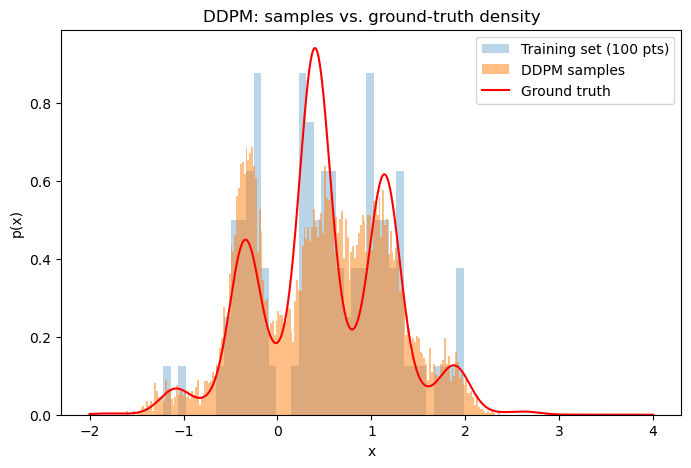

In [13]:
if is_notebook():
    torch.manual_seed(0)
    grid = torch.linspace(-2, 4, 4001)
    train_samples = sample(100, grid).unsqueeze(-1)

    log_p = logp_data_unnorm(grid)
    log_p = log_p - log_p.max()
    p_unnorm = log_p.exp()
    p = p_unnorm / torch.trapz(p_unnorm, grid)

    ddpm = DDPM(x_dim=1, hidden=[128, 128], T=500, beta_start=1e-4, beta_end=0.05)
    optimizer = optim.Adam(ddpm.parameters(), lr=5e-4)

    n_epochs = 20000
    for epoch in range(n_epochs):
        loss = ddpm.loss(train_samples)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 2000 == 0:
            print(f"epoch {epoch + 1:5d} / {n_epochs}    loss = {loss.item():.4f}")

    ddpm.eval()
    x_samples = ddpm.sample(10000).cpu().numpy().flatten()

    plt.figure(figsize=(8, 5))
    plt.hist(train_samples.numpy().flatten(), bins=40, density=True, alpha=0.3,
             label='Training set (100 pts)')
    plt.hist(x_samples, bins=200, density=True, alpha=0.5, label='DDPM samples')
    plt.plot(grid.numpy(), p.numpy(), 'r-', label='Ground truth')
    plt.xlabel('x')
    plt.ylabel('p(x)')
    plt.legend()
    plt.title('DDPM: samples vs. ground-truth density')
    plt.show()


You should see a more robust empirical fit from DDPMs compared to VAEs.